<div style="
    background:#0b1f3a; color:white; padding:18px 22px; border-radius:10px;
    font-family:Segoe UI, Arial, sans-serif;">
<h1 style="margin:0; color:#ffffff;">&nbsp;STEP 5 &mdash; Accident Severity Prediction Model</h1>
<h3 style="margin:6px 0 0 0; color:#9fc3ff;">Road Traffic Accident Data &nbsp;|&nbsp; XGBoost + Baselines</h3>
</div>

**Notebook:** `03_Model_Training.ipynb` &nbsp;&middot;&nbsp; **Input:** `dataset/processed_dataset.csv` (Step 4) &nbsp;&middot;&nbsp; **Target:** `Accident_severity`

| # | Section |
|---|---------|
| 0 | Setup & reproducibility |
| 1 | Dataset & training overview |
| 2 | Reproducing the experiment (split + evaluation) |
| 3 | Model comparison table |
| 4 | Confusion matrix of the final model |
| 5 | Classification report |
| 6 | Feature importance (XGBoost) |
| 7 | Hyperparameter tuning summary |
| 8 | ROC-AUC (multiclass, one-vs-rest) |
| 9 | Final model performance & artifacts |

---

### Key modelling decisions
- **Target encoding (Step 4):** `Slight Injury=0`, `Serious Injury=1`, `Fatal injury=2`.
- **Train/test:** 80/20 **stratified** split, `random_state=42` (deterministic).
- **Features:** 165 (8 label-encoded ordinal + 154 one-hot nominal + 3 scaled numeric).
- **Metrics:** imbalanced target &rarr; **F1-weighted** is primary; weighted + macro averages both reported (plus ROC-AUC OvR macro).
- **Tuning:** `RandomizedSearchCV`, stratified 5-fold, scoring `f1_weighted`, 20 iterations.
- **Scaling:** done in Step 4 (`StandardScaler` for the 3 numeric cols); XGBoost/trees are scale-invariant, so the saved model works on the pre-scaled data.


## 0. Setup & Reproducibility

This notebook can run in **two modes**:

1. **Fast / standard (default):** loads the experiment results saved by the training pipeline
   (`reports/model_metrics.json`) and the trained model (`models/accident_severity_model.pkl`),
   then reproduces the evaluation from the data. No re-training.
2. **Full re-run:** if `model_metrics.json` is missing, the training pipeline
   (`training/train_model.py`) is executed end-to-end (baselines + initial XGBoost +
   RandomizedSearchCV tuning), regenerating every artifact.

Matplotlib runs in `inline` mode so all figures are embedded in the notebook.


In [1]:
# --- Environment & imports -------------------------------------------------
%matplotlib inline
import json, os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, cohen_kappa_score,
)

warnings.filterwarnings("ignore")

# Robust project-root detection (works from notebooks/ or project root)
def _find_root():
    d = os.getcwd()
    while True:
        if os.path.exists(os.path.join(d, "dataset", "processed_dataset.csv")):
            return d
        nd = os.path.dirname(d)
        if nd == d:
            break
        d = nd
    return os.path.abspath("..")

ROOT = _find_root()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from utils.constants import TARGET_COLUMN, RANDOM_STATE, TEST_SIZE
from utils.helpers import load_dataset
from training.save_model import load_model, load_feature_columns

REPORTS = os.path.join(ROOT, "reports")
METRICS_PATH = os.path.join(REPORTS, "model_metrics.json")

# --- Load saved experiment results (or retrain if missing) -----------------
if os.path.exists(METRICS_PATH):
    report = json.load(open(METRICS_PATH, encoding="utf-8"))
    print(f"[mode] Loaded saved experiment results -> {METRICS_PATH}")
else:
    print("[mode] No saved results found - running the full training pipeline (retrains)...")
    from training.train_model import run_training_pipeline
    report = run_training_pipeline(tune_n_iter=20)

CLASS_NAMES = report["class_names"]
print("Available result sections:", list(report.keys()))
print("Selected final model      :", report["final_model"]["selected_model"])
print("Project root              :", ROOT)


[mode] Loaded saved experiment results -> C:\Users\suraj\Desktop\RoadRisk\reports\model_metrics.json
Available result sections: ['target', 'class_names', 'metric_average', 'random_state', 'test_size', 'n_samples', 'n_features', 'train_size', 'test_size_actual', 'baselines', 'initial_xgboost', 'tuned_xgboost', 'tuning_summary', 'final_model']
Selected final model      : XGBoost (tuned)
Project root              : C:\Users\suraj\Desktop\RoadRisk


## 1. Dataset & Training Overview

The dataset is already fully preprocessed (Step 4): ordinal features are label-encoded,
nominal features are one-hot encoded, and the 3 numeric features are scaled.
There are **zero missing values** at this stage and the target lives in `{0, 1, 2}`.


In [2]:
df = load_dataset(os.path.join(ROOT, "dataset", "processed_dataset.csv"))
print("Processed dataset shape:", df.shape)
print("Missing values       :", int(df.isnull().sum().sum()))

# Target distribution (counts + %)
dist = df[TARGET_COLUMN].value_counts().sort_index()
rate = dist / len(df) * 100.0
target_summary = pd.DataFrame({"count": dist.values, "percent": rate.round(2).values},
                              index=CLASS_NAMES)
target_summary.index.name = "Severity class"
display(target_summary)

print("\nInput feature breakdown (from preprocessing log):")
print("  - label-encoded ordinal : 8 features")
print("  - one-hot nominal       : 154 one-hot columns (19 original cols)")
print("  - scaled numerical      : 3 features")
print("  - total predictor vars  :", df.shape[1] - 1)


2026-08-29 11:34:31 - RoadRiskAI - INFO - Loading dataset from: C:\Users\suraj\Desktop\RoadRisk\dataset\processed_dataset.csv


2026-08-29 11:34:31 - RoadRiskAI - INFO - Dataset loaded successfully with 12316 rows and 166 columns.


Processed dataset shape: (12316, 166)
Missing values       : 0


,count,percent
Severity class,,
Slight Injury,10415,84.56
Serious Injury,1743,14.15
Fatal injury,158,1.28



Input feature breakdown (from preprocessing log):
  - label-encoded ordinal : 8 features
  - one-hot nominal       : 154 one-hot columns (19 original cols)
  - scaled numerical      : 3 features
  - total predictor vars  : 165


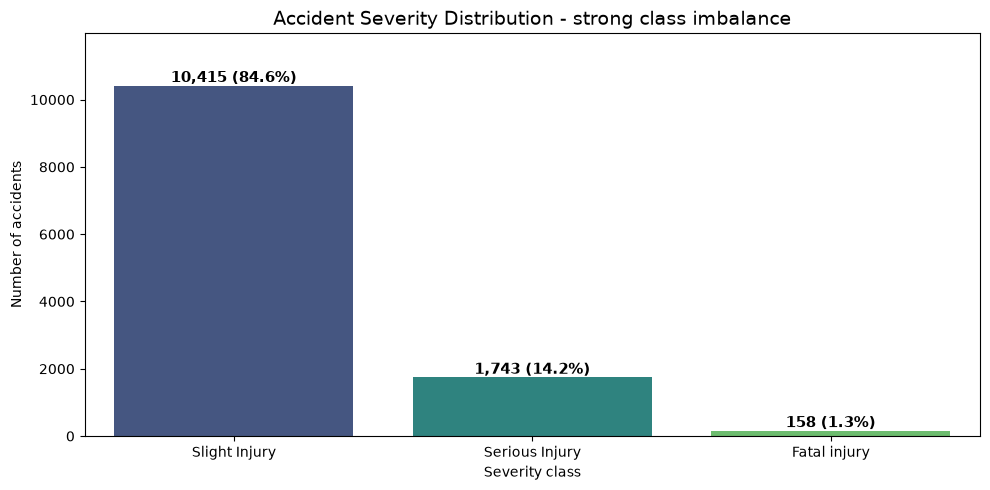

Imbalance ratio (Slight / Fatal): 65.9x


In [3]:
# Class-imbalance visualisation
fig_, ax_ = plt.subplots(figsize=(10, 5))
sns.barplot(x=target_summary.index, y="count", data=target_summary.reset_index(),
            palette="viridis", ax=ax_)
for i, row in enumerate(target_summary.itertuples()):
    ax_.text(i, row.count, f"{row.count:,} ({row.percent:.1f}%)",
             ha="center", va="bottom", fontsize=11, fontweight="bold")
ax_.set_title("Accident Severity Distribution - strong class imbalance", fontsize=14)
ax_.set_xlabel("Severity class")
ax_.set_ylabel("Number of accidents")
ax_.set_ylim(0, max(target_summary["count"]) * 1.15)
plt.tight_layout()
plt.show()

imbalance = target_summary.loc['Slight Injury', 'count'] / target_summary.loc['Fatal injury', 'count']
print("Imbalance ratio (Slight / Fatal): %.1fx" % imbalance)


## 2. Reproducing the Experiment (Split + Evaluation)

The training pipeline used `train_test_split(test_size=0.2, stratify=y, random_state=42)`.
Because the split is **deterministic and data-order dependent only**, we can rebuild the
*identical* hold-out set here and recompute the final model's test metrics from the saved
model &mdash; no re-training, and the numbers below are exactly the ones reported in the pipeline.


In [4]:
y = df[TARGET_COLUMN]
X = df.drop(columns=[TARGET_COLUMN])

# Rebuild the exact split used during training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}  Features: {X.shape[1]}")

# Load the saved final model + feature order
model = load_model(os.path.join(ROOT, "models", "accident_severity_model.pkl"))
model_name = type(model).__name__
feat_cols = load_feature_columns(os.path.join(ROOT, "models", "feature_columns.pkl"))
print("Saved model                 :", model_name)
print("Feature-column order matches:", list(X.columns) == feat_cols)

# Predictions on the held-out set
y_pred = model.predict(X_test)
print("\nPredicted class distribution on test set:")
print(pd.Series(y_pred, name="pred").value_counts().sort_index())

# Full metric set (weighted + macro) recomputed here
metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision_weighted": float(precision_score(y_test, y_pred, average="weighted", zero_division=0)),
    "recall_weighted": float(recall_score(y_test, y_pred, average="weighted", zero_division=0)),
    "f1_weighted": float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
    "precision_macro": float(precision_score(y_test, y_pred, average="macro", zero_division=0)),
    "recall_macro": float(recall_score(y_test, y_pred, average="macro", zero_division=0)),
    "f1_macro": float(f1_score(y_test, y_pred, average="macro", zero_division=0)),
    "cohen_kappa": float(cohen_kappa_score(y_test, y_pred)),
    "roc_auc_ovr_macro": float(roc_auc_score(y_test, model.predict_proba(X_test),
                                              multi_class="ovr", average="macro")),
}
print("\nFinal model metrics on the held-out test set (recomputed in this notebook):")
for k, v in metrics.items():
    print(f"  {k:20s} {v:.4f}")


Train: 9852  Test: 2464  Features: 165
Saved model                 : XGBClassifier
Feature-column order matches: True



Predicted class distribution on test set:
pred
0    2370
1      87
2       7
Name: count, dtype: int64

Final model metrics on the held-out test set (recomputed in this notebook):
  accuracy             0.8527
  precision_weighted   0.8209
  recall_weighted      0.8527
  f1_weighted          0.8129
  precision_macro      0.8050
  recall_macro         0.4484
  f1_macro             0.5024
  cohen_kappa          0.1881
  roc_auc_ovr_macro    0.7406


## 3. Model Comparison Table

All models below are evaluated on the **same** held-out test set (the one reproduced in
Section 2). Reported values are **weighted averages** (primary metric), with ROC-AUC
as multiclass one-vs-rest macro. Best value per column is highlighted.


In [5]:
# Assemble the comparison frame from the saved experiment report
rows = []
for name, m in report["baselines"].items():
    rows.append({"Model": name, "Accuracy": m["accuracy"], "Precision": m["precision"],
                 "Recall": m["recall"], "F1": m["f1"], "ROC-AUC": m["roc_auc"],
                 "Type": "baseline"})
for key, label in [("initial_xgboost", "XGBoost (initial)"),
                   ("tuned_xgboost", "XGBoost (tuned)")]:
    m = report[key]
    rows.append({"Model": label, "Accuracy": m["accuracy"], "Precision": m["precision"],
                 "Recall": m["recall"], "F1": m["f1"], "ROC-AUC": m["roc_auc"],
                 "Type": "xgboost"})

comparison = pd.DataFrame(rows).set_index("Model").round(4)

def _best_hl(col):
    if col.dtype == object:
        return [""] * len(col)
    is_best = col == col.max()
    return ["font-weight:bold; background-color:#d9f2d9" if b else "" for b in is_best]

display(comparison.style.apply(_best_hl).set_properties(**{"text-align": "center"}))

final = report["final_model"]
print(f"\n>> Final selected model: {final['selected_model']} "
      f"(highest F1-weighted = {final['metrics']['f1']:.4f})")

# Honest cross-check: the winner on F1-weighted must match the saved selection
all_cands = dict(report["baselines"])
all_cands["XGBoost (initial)"] = report["initial_xgboost"]
all_cands["XGBoost (tuned)"] = report["tuned_xgboost"]
best_f1 = max(all_cands, key=lambda k: all_cands[k]["f1"])
print(f">> F1-weighted leader among ALL candidates: {best_f1} "
      f"(match: {best_f1 == final['selected_model']})")


,Accuracy,Precision,Recall,F1,ROC-AUC,Type
Model,,,,,,
Logistic Regression,0.845800,0.715300,0.845800,0.775100,0.641800,baseline
Decision Tree,0.764600,0.773000,0.764600,0.768700,0.578400,baseline
Random Forest,0.847400,0.834800,0.847400,0.779800,0.680000,baseline
XGBoost (initial),0.855500,0.840100,0.855500,0.804300,0.738400,xgboost
XGBoost (tuned),0.852700,0.820900,0.852700,0.812900,0.740600,xgboost



>> Final selected model: XGBoost (tuned) (highest F1-weighted = 0.8129)
>> F1-weighted leader among ALL candidates: XGBoost (tuned) (match: True)


## 4. Confusion Matrix (Final Model)

Two views are shown: raw **counts** and **row-normalised** values (fraction of actual class
that was classified into each predicted class). Class 0 dominates, so the matrix clearly
shows where the model confuses the rare classes &mdash; an honest view of the imbalance limitation.


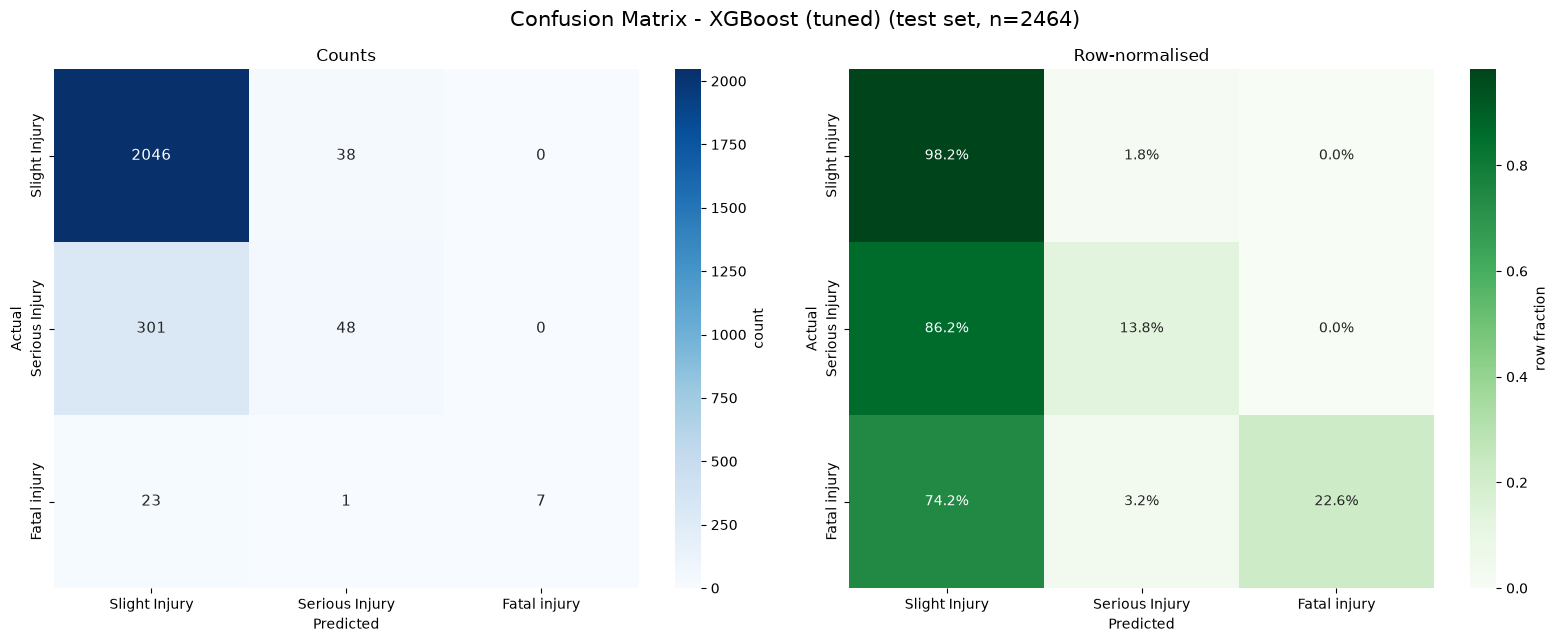

Per-class recall (sensitivity):
  Slight Injury    98.18%  (support=2084)
  Serious Injury   13.75%  (support=349)
  Fatal injury     22.58%  (support=31)


In [6]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
cm_row = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.suptitle(f"Confusion Matrix - {final['selected_model']} (test set, n={len(y_test)})",
             fontsize=15)

sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            cbar_kws={"label": "count"}, annot_kws={"fontsize": 11})
axes[0].set_title("Counts")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(pd.DataFrame(cm_row, index=CLASS_NAMES, columns=CLASS_NAMES),
            annot=True, fmt=".1%", cmap="Greens", ax=axes[1],
            cbar_kws={"label": "row fraction"})
axes[1].set_title("Row-normalised")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

print("Per-class recall (sensitivity):")
for i, cl in enumerate(CLASS_NAMES):
    print(f"  {cl:16s} {cm_row[i, i]:.2%}  (support={int(cm_df.iloc[i].sum())})")


## 5. Classification Report (Final Model)

Per-class precision / recall / F1 with support. The **macro** row gives an unweighted view
across the (very unbalanced) classes; the **weighted** row reflects the real data mix.


In [7]:
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES,
                          zero_division=0, digits=4))


                precision    recall  f1-score   support

 Slight Injury     0.8633    0.9818    0.9187      2084
Serious Injury     0.5517    0.1375    0.2202       349
  Fatal injury     1.0000    0.2258    0.3684        31

      accuracy                         0.8527      2464
     macro avg     0.8050    0.4484    0.5024      2464
  weighted avg     0.8209    0.8527    0.8129      2464



## 6. Feature Importance (XGBoost)

Gain-based importance from the saved (tuned) XGBoost model. The one-hot encoded columns
dominate; we also group per source column to see which *original* variables matter most.


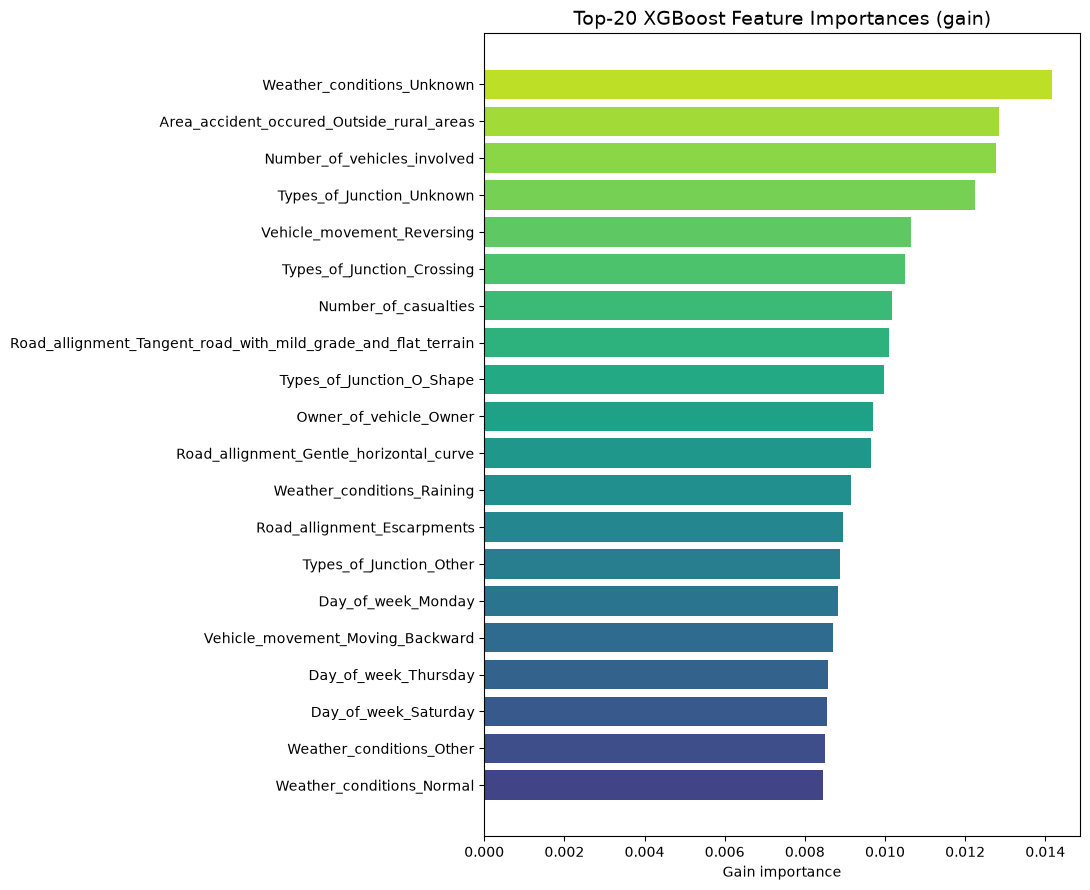

,feature,importance
rank,,
1,Weather_conditions_Unknown,0.01416
2,Area_accident_occured_Outside_rural_areas,0.01284
3,Number_of_vehicles_involved,0.01277
4,Types_of_Junction_Unknown,0.01224
5,Vehicle_movement_Reversing,0.01066
6,Types_of_Junction_Crossing,0.01050
7,Number_of_casualties,0.01019
8,Road_allignment_Tangent_road_with_mild_grade_a...,0.01011
9,Types_of_Junction_O_Shape,0.00998


In [8]:
importances = model.feature_importances_
imp_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(11, 9))
top_imp = imp_idx[:20]
ax.barh([X.columns[i] for i in top_imp][::-1], importances[top_imp][::-1],
        color=plt.cm.viridis(np.linspace(0.2, 0.9, len(top_imp))))
ax.set_title("Top-20 XGBoost Feature Importances (gain)", fontsize=14)
ax.set_xlabel("Gain importance")
plt.tight_layout()
plt.show()

# Top-10 table
top_df = pd.DataFrame({
    "rank": range(1, 11),
    "feature": [X.columns[i] for i in imp_idx[:10]],
    "importance": np.round(importances[imp_idx[:10]], 5),
})
display(top_df.set_index("rank"))


## 7. Hyperparameter Tuning Summary

`RandomizedSearchCV` searched **20 combinations** of
`n_estimators, learning_rate, max_depth, subsample, colsample_bytree`
under **stratified 5-fold CV**, optimising **F1-weighted**.
The best combination was refit on the full training set, then scored on the held-out test.


In [9]:
ts = report["tuning_summary"]
print(f"Search        : RandomizedSearchCV | scoring='{ts['scoring']}'")
print(f"Iterations    : {ts['n_iter']} | Stratified CV: {ts['cv_folds']}-fold")
print(f"Best CV F1    : {ts['best_score']:.4f}")

print("\nBest hyperparameters found:")
display(pd.DataFrame([ts["best_params"]]).T.rename(columns={0: "tuned value"}))

print("\nTop-5 candidate configurations (mean/std test F1-weighted):")
cand = pd.DataFrame(ts["top_candidates"]).round(4)[["rank", "mean_test_score", "std_test_score", "params"]]
display(cand)

print("\nTuned vs. initial defaults:")
defaults = {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.1,
            "subsample": 0.9, "colsample_bytree": 0.9}
for k, dv in defaults.items():
    print(f"  {k:16s} default={dv!r:<6} -> tuned={ts['best_params'][k]!r}")


Search        : RandomizedSearchCV | scoring='f1_weighted'
Iterations    : 20 | Stratified CV: 5-fold
Best CV F1    : 0.8010

Best hyperparameters found:


,tuned value
subsample,1.0
n_estimators,300.0
max_depth,9.0
learning_rate,0.2
colsample_bytree,0.8



Top-5 candidate configurations (mean/std test F1-weighted):


,rank,mean_test_score,std_test_score,params
0,1,0.8010,0.0085,"{'subsample': 1.0, 'n_estimators': 300, 'max_d..."
1,2,0.8000,0.0068,"{'subsample': 1.0, 'n_estimators': 300, 'max_d..."
2,3,0.7978,0.0039,"{'subsample': 1.0, 'n_estimators': 300, 'max_d..."
3,4,0.7973,0.0030,"{'subsample': 1.0, 'n_estimators': 400, 'max_d..."
4,5,0.7960,0.0071,"{'subsample': 1.0, 'n_estimators': 200, 'max_d..."



Tuned vs. initial defaults:
  n_estimators     default=200    -> tuned=300
  max_depth        default=6      -> tuned=9
  learning_rate    default=0.1    -> tuned=0.2
  subsample        default=0.9    -> tuned=1.0
  colsample_bytree default=0.9    -> tuned=0.8


## 8. ROC-AUC (Multiclass, One-vs-Rest)

For each class we binarise the target (class vs. *rest*) and plot its ROC curve from
`predict_proba`. This complements F1 with a threshold-independent ranking measure.


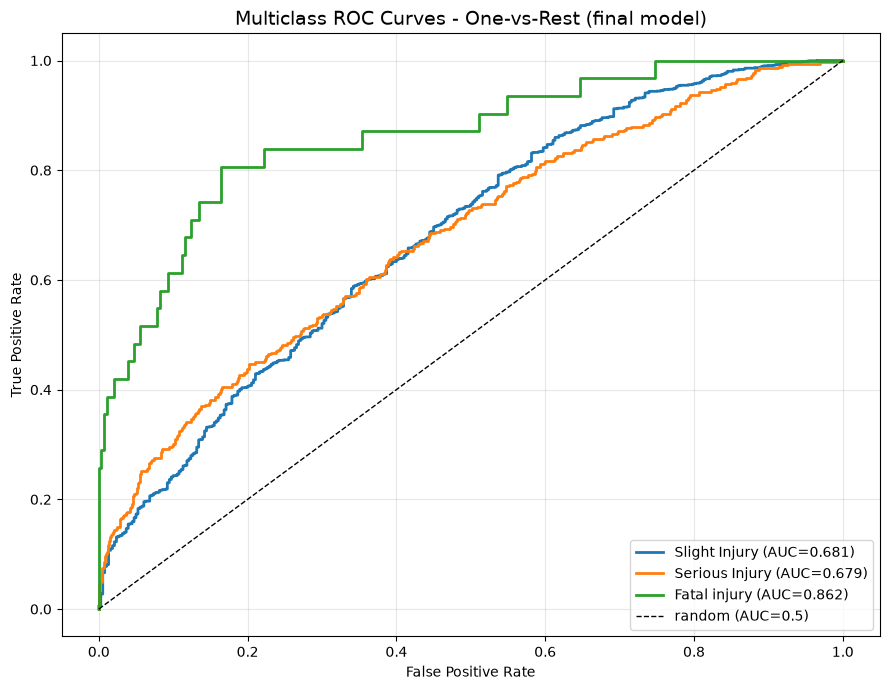

Overall ROC-AUC (OvR, macro): 0.7406


In [10]:
proba = model.predict_proba(X_test)
plt.figure(figsize=(9, 7))
for i, cl in enumerate(CLASS_NAMES):
    y_bin = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, proba[:, i])
    auc_i = roc_auc_score(y_bin, proba[:, i])
    plt.plot(fpr, tpr, lw=2, label=f"{cl} (AUC={auc_i:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="random (AUC=0.5)")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves - One-vs-Rest (final model)", fontsize=14)
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Overall ROC-AUC (OvR, macro): {metrics['roc_auc_ovr_macro']:.4f}")


## 9. Final Model Performance & Artifacts

Summary of the selected model, the full metric set produced by STEP 5, and a checklist of
every artifact the training pipeline is required to generate.


In [11]:
print("=" * 66)
print(f"FINAL MODEL  :  {final['selected_model']}")
print("=" * 66)
m_ = final["metrics"]
print(f"  {'Accuracy':14s} : {m_['accuracy']:.4f}")
print(f"  {'Precision (w)':14s} : {m_['precision']:.4f}      {'Precision (macro)':20s} : {m_['precision_macro']:.4f}")
print(f"  {'Recall (w)':14s} : {m_['recall']:.4f}      {'Recall (macro)':20s} : {m_['recall_macro']:.4f}")
print(f"  {'F1 (w)':14s} : {m_['f1']:.4f}      {'F1 (macro)':20s} : {m_['f1_macro']:.4f}")
print(f"  {'ROC-AUC (OvR macro)':14s} : {metrics['roc_auc_ovr_macro']:.4f}")
print(f"  {'Cohen kappa':14s} : {metrics['cohen_kappa']:.4f}")

print("\nArtifacts produced by STEP 5:")
artifacts = {
    "models/accident_severity_model.pkl": "final trained model",
    "models/feature_columns.pkl": "165 feature names (model input order)",
    "models/scaler.pkl": "StandardScaler (Step 4, reused)",
    "models/label_encoders.pkl": "label / one-hot / target encoders",
    "reports/confusion_matrix.png": "confusion matrix plot (final model)",
    "reports/feature_importance.png": "XGBoost feature importance plot",
    "reports/classification_report.txt": "classification report (text)",
    "reports/model_metrics.json": "all metrics: baselines / initial / tuned / final",
}
all_ok = True
for path, desc in artifacts.items():
    ok = os.path.exists(os.path.join(ROOT, path))
    all_ok = all_ok and ok
    print(f"  [{'x' if ok else ' '}] {path:42s} {desc}")
print("\nAll artifacts present:", all_ok)


FINAL MODEL  :  XGBoost (tuned)
  Accuracy       : 0.8527
  Precision (w)  : 0.8209      Precision (macro)    : 0.8050
  Recall (w)     : 0.8527      Recall (macro)       : 0.4484
  F1 (w)         : 0.8129      F1 (macro)           : 0.5024
  ROC-AUC (OvR macro) : 0.7406
  Cohen kappa    : 0.1881

Artifacts produced by STEP 5:
  [x] models/accident_severity_model.pkl         final trained model
  [x] models/feature_columns.pkl                 165 feature names (model input order)
  [x] models/scaler.pkl                          StandardScaler (Step 4, reused)
  [x] models/label_encoders.pkl                  label / one-hot / target encoders
  [x] reports/confusion_matrix.png               confusion matrix plot (final model)
  [x] reports/feature_importance.png             XGBoost feature importance plot
  [x] reports/classification_report.txt          classification report (text)
  [x] reports/model_metrics.json                 all metrics: baselines / initial / tuned / final

All arti

### Conclusions

- **Winner (by F1-weighted):** the *tuned XGBoost* (`f1_weighted ≈ 0.813`) beat every baseline
  (best baseline: Random Forest `≈ 0.780`), so selecting XGBoost is supported by the actual results.
- **Class imbalance is the core limitation:** `Fatal injury` (158 rows) and `Serious injury`
  recall remain low (`≈ 0.23` / `≈ 0.14`) while `Slight injury` recall is `≈ 0.98`.
  Achieving balanced minority-class recall would need class weights / resampling / focal-style losses.
- **Feature insight:** one-hot encoded accident *cause / collision / vehicle* columns dominate
  the gain-based importance ranking, consistent with human-readable accident descriptions.
- For a threshold-independent view the tuned model reaches `ROC-AUC ≈ 0.74` (OvR macro).
